wandbからダウンロードしたsuccess/timeのcsvを読み込んで、グラフを描画するスクリプト。
x軸をglobal stepにしてダウンロードすることを忘れずに。

In [1]:
# Success/timeのデータ使う
sapg = {
        "csv": "/Users/naokishitanda/my_local_gitcode/sapg2/data/exp_0127/0203/Hand-Reorientation/src/SAPG_2.csv",
        "label": "SAPG(2seed)",
        "num_data": 2,
    }

"""
# βを0に固定し、γを大きくしていく実験。
(1,1,1) = 1,1e-4, 1e-3
(1,0,1), (1,0,10), (1,0,20), (1,0,40), (1,0,80), (1,0,160), (1,0,320), (1,0,640)
"""
title = "Hand Reorientation α=1, λ=0.1 (1_1_1=1,1e-4,1e-3)"


data = [
    {
        "label": "PPO(2)",
        "csv": "/Users/naokishitanda/my_local_gitcode/sapg2/data/exp_0127/0203/Hand-Reorientation/src/PPO_2.csv",
        "num_data": 2,
    },
    {
        "label": "1-0-320(1)",
        "csv": "/Users/naokishitanda/my_local_gitcode/sapg2/data/exp_0127/0203/Hand-Reorientation/src/1-0-320-01_1.csv",
        "num_data": 1,
    },

    
    
    
]


In [2]:
# sapgのデータを可視化する(stap数ごとのデータがrunごとにmean, min. maxの順で並んでいる。つまり合計24列。ただし抜けている箇所もある)
# meanだけを取り出して、平均と標準偏差をプロットする
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 複数シードのデータ用
def plot_success_step_multiseed(data_dict, num_data, plot_mean_dev=False, lw=1, alpha=0.3):
    assert num_data > 1, "num_data must be greater than 1"
    # meanを抽出するための列番号を取得
    indices = [i for i in range(4, num_data*6, 6)]
    # csvファイルを読み込む
    df = pd.read_csv(data_dict["csv"])
    # データとステップ数を取り出す
    steps = df.iloc[:,[0]].values.tolist()
    steps = np.array(steps).reshape(-1)
    data = df.iloc[:,indices]
    data_array = data.values.tolist()
    data_array = np.array(data_array).T
    # 列ごとに[[steps], [mean]]にしてリストに格納
    data_array = [[steps, data] for data in data_array]
    data_array = np.array(data_array)    
        
    if not plot_mean_dev:
        for i in range(data_array.shape[0]):
            plt.plot(data_array[i][0], data_array[i][1], label=f"{data_dict["label"]}_run{i}", lw=lw)
    else:
        # np.arrayのnan部分を線形補完
        for i in range(data_array.shape[0]):
            nan_idx = np.isnan(data_array[i][1])
            x = np.arange(len(data_array[i][1]))
            data_array[i][1][nan_idx] = np.interp(x[nan_idx], x[~nan_idx], data_array[i][1][~nan_idx])
            
        # 平均と標準偏差を計算
        mean = np.mean(data_array[:,1], axis=0)
        std = np.std(data_array[:,1], axis=0)
        # プロット
        plt.plot(steps, mean, label=data_dict["label"], lw=lw)
        plt.fill_between(steps, mean-std, mean+std, alpha=alpha)
        
# 単一シードのデータ用 
def plot_success_step_singleseed(data_dict, lw=1):
    # meanを抽出するための列番号を取得
    indices = [4]
    # csvファイルを読み込む
    df = pd.read_csv(data_dict["csv"])
    # データとステップ数を取り出す
    steps = df.iloc[:,[0]].values.tolist()
    steps = np.array(steps).reshape(-1)
    data = df.iloc[:,indices]
    data_array = data.values.tolist()
    data_array = np.array(data_array).T
    # 列ごとに[[steps], [mean]]にしてリストに格納
    data_array = [[steps, data] for data in data_array]
    data_array = np.array(data_array)    
        
    plt.plot(data_array[0][0], data_array[0][1], label=f"{data_dict["label"]}", lw=lw) 


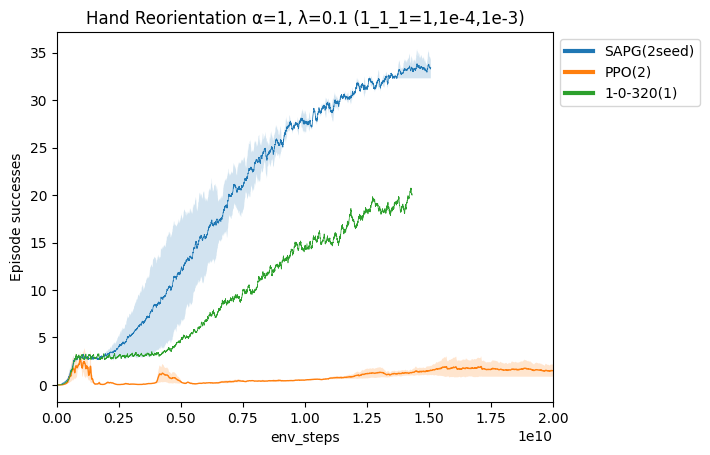

In [3]:
# SAPGのデータをプロット
plot_success_step_multiseed(sapg, num_data=sapg["num_data"],  plot_mean_dev=True, lw=0.5, alpha=0.2)
# testのデータをプロット
#plot_success_step_singleseed(test, lw=1)
for d in data:
    if d["num_data"] == 1:
        plot_success_step_singleseed(d, lw=0.5)
    else:
        plot_success_step_multiseed(d, num_data=d["num_data"], plot_mean_dev=True, lw=1, alpha=0.2)

# 表示
plt.xlabel("env_steps")
plt.ylabel("Episode successes") # Success/timeのデータ使う
legend=plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.title(title)
plt.xlim(0, 2e10)
for line in legend.get_lines():
    line.set_linewidth(3.0)
plt.show()
